# Software comparison: prot2exon vs ensembldb, TransVar, Ensembl REST

Three established alternatives are run against the same 5,000-query
stratified set. This notebook loads their per-tool tables and renders
the figure that goes in the paper's Table 1.

See the [Speed vs other tools](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#speed-vs-other-tools)
wiki section for the full 4-tool table + comparator-specific notes (why
each tool, what each tool's denominator means, the TransVar envelope-only
caveat).

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import pandas as pd
from pathlib import Path

DATA = Path.home() / "Desktop" / "protein2genomic_data"
V113 = DATA / "validation_v113"     # contains rest_table.tsv + transvar_table.tsv
V86  = DATA / "validation_v86"

assert (V86  / "table1.tsv").exists()
assert (V113 / "rest_table.tsv").exists()
assert (V113 / "transvar_table.tsv").exists()
print("loaded the three external tables")

loaded the three external tables


## 1. Per-tool agreement vs prot2exon

Each external tool answers a slightly different question, so we honour the
differences by reporting both the raw exact-match count **and** the
denominator each tool returned data for. (e.g. TransVar ships an older
Ensembl release than our queries reference, so 3,239 / 5,000 fall into
`only_prot2exon` for it, which is annotation drift, not disagreement.)

In [2]:
def _read_external(path: Path) -> pd.Series:
    # Header line starts with a '#' tool tag; skip it.
    df = pd.read_csv(path, sep="\t", comment="#")
    return df.query("category == 'OVERALL'").iloc[0]

ens   = pd.read_csv(V86 / "table1.tsv", sep="\t").query("category == 'OVERALL'").iloc[0]
rest  = _read_external(V113 / "rest_table.tsv")
tvar  = _read_external(V113 / "transvar_table.tsv")

rows = []
for name, r, denom_col in [
    ("ensembldb", ens, "n"),
    ("TransVar", tvar, "exact_match"),
    ("Ensembl REST", rest, "n"),
]:
    # both-returned denominator: exact + off_by_one + structural
    both = r["exact_match"] + r["off_by_one"] + r["structural_mismatch"]
    if name == "TransVar":
        # TransVar's intersection denominator is documented as 1,761: the
        # queries where TransVar has the ENST in its bundled annotation.
        # exact_match alone gives us that.
        denom = both
    else:
        denom = r["n"] if name == "ensembldb" else both
    pct = 100 * r["exact_match"] / max(1, denom)
    rows.append({"tool": name, "exact_match": int(r["exact_match"]),
                 "denominator": int(denom), "exact_pct": pct,
                 "off_by_one": int(r["off_by_one"]),
                 "only_prot2exon": int(r["only_prot2exon"])})
agree = pd.DataFrame(rows)
agree

,tool,exact_match,denominator,exact_pct,off_by_one,only_prot2exon
0,ensembldb,5000,5000,100.0,0,0
1,TransVar,1761,1761,100.0,0,3239
2,Ensembl REST,983,1000,98.3,17,0


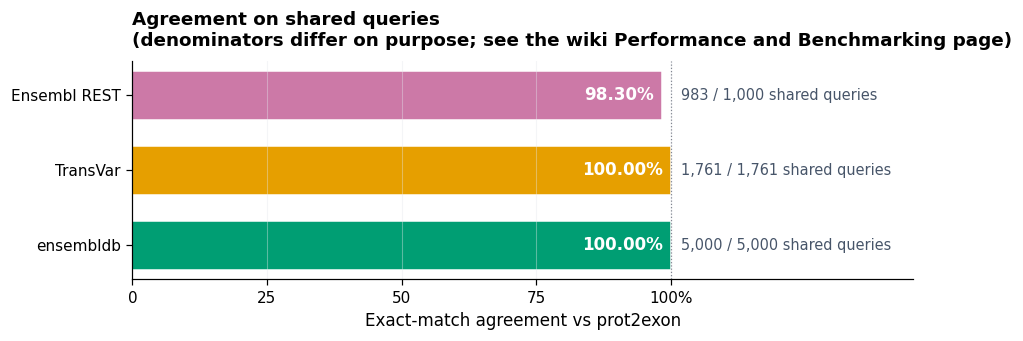

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.2))
palette = [COLORS['ensembldb'], COLORS['transvar'], COLORS['rest']]
bars = ax.barh(agree["tool"], agree["exact_pct"],
               color=palette, edgecolor="white", height=0.65)
for b, r in zip(bars, agree.itertuples()):
    ax.text(102, b.get_y() + b.get_height()/2,
            f"{r.exact_match:,} / {r.denominator:,} shared queries",
            va="center", fontsize=9.5, color="#475569")
    ax.text(r.exact_pct - 1.5, b.get_y() + b.get_height()/2,
            f"{r.exact_pct:.2f}%", va="center", ha="right",
            fontsize=11, fontweight="semibold", color="white")
ax.set_xlim(0, 145)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact-match agreement vs prot2exon")
ax.set_title("Agreement on shared queries\n"
             "(denominators differ on purpose; see the wiki Performance and Benchmarking page)",
             loc='left')
ax.grid(axis='x', alpha=0.4, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

## 2. Throughput at N = 10,000

The 4-tool runtime side. Numbers below are from the scaling benchmark
(see the next notebook for the raw scaling table).

In [4]:
# Headline numbers from benchmarks/README.md / wiki:Benchmarks.
runtime = pd.DataFrame([
    {"tool": "prot2exon",   "wall_s": 1.71,    "throughput_qps": 5847,  "rss_mb": 788},
    {"tool": "ensembldb",   "wall_s": 1558.0,  "throughput_qps": 6,     "rss_mb": 1252},
    {"tool": "TransVar",    "wall_s": 7.54,    "throughput_qps": 1326,  "rss_mb": 284},
    {"tool": "Ensembl REST","wall_s": 9180.0,  "throughput_qps": 1.09,  "rss_mb": float('nan')},
])
runtime

,tool,wall_s,throughput_qps,rss_mb
0,prot2exon,1.71,5847.00,788.0
1,ensembldb,1558.00,6.00,1252.0
2,TransVar,7.54,1326.00,284.0
3,Ensembl REST,9180.00,1.09,NaN


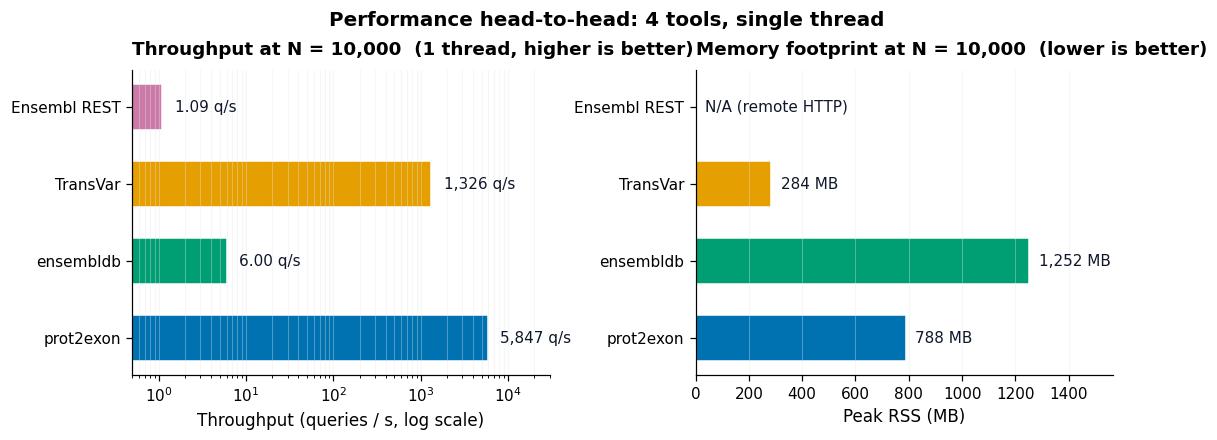

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6),
                         gridspec_kw={'wspace': 0.35})
tool_colors = [COLORS['prot2exon'], COLORS['ensembldb'],
               COLORS['transvar'],   COLORS['rest']]

# --- Throughput (log scale so 5,847 q/s and 1.09 q/s share an axis) ---
axes[0].barh(runtime["tool"], runtime["throughput_qps"],
             color=tool_colors, edgecolor="white", height=0.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("Throughput (queries / s, log scale)")
axes[0].set_title("Throughput at N = 10,000  (1 thread, higher is better)",
                  loc='left')
for i, v in enumerate(runtime["throughput_qps"]):
    label = f"{v:,.0f} q/s" if v >= 10 else f"{v:.2f} q/s"
    axes[0].text(v * 1.4, i, label, va="center", fontsize=10, color="#0f172a")
axes[0].set_xlim(0.5, 30_000)
axes[0].grid(axis='x', which='both', alpha=0.35, lw=0.7); axes[0].grid(axis='y', visible=False)

# --- Peak RSS ---
rss = runtime["rss_mb"].fillna(0)
axes[1].barh(runtime["tool"], rss,
             color=tool_colors, edgecolor="white", height=0.6)
axes[1].set_xlabel("Peak RSS (MB)")
axes[1].set_title("Memory footprint at N = 10,000  (lower is better)",
                  loc='left')
for i, v in enumerate(rss):
    txt = f"{int(v):,} MB" if v > 0 else "N/A (remote HTTP)"
    axes[1].text(v + 35, i, txt, va="center", fontsize=10, color="#0f172a")
axes[1].set_xlim(0, max(rss) * 1.25)
axes[1].grid(axis='x', alpha=0.35, lw=0.7); axes[1].grid(axis='y', visible=False)

fig.suptitle("Performance head-to-head: 4 tools, single thread",
             fontsize=13, fontweight="semibold", y=1.03)
plt.show()

## 3. A second Bioconductor implementation: GenomicFeatures::proteinToGenome

`proteinToGenome` ships in **two** R/Bioconductor packages. ensembldb's
version is SQLite-backed (the one in the table above); GenomicFeatures
has a separate GRangesList method that maps in memory. Skipping SQLite
makes the GRanges path faster than ensembldb, but it is still an R-level
per-query loop.

The numbers below were **freshly measured** on this machine: 1,000
matched (v86) queries, one thread, each tool in its own process
(`benchmarks/proteintogenome_bench.R`). prot2exon, GenomicFeatures, and
ensembldb returned **identical coordinates on all 1,000 queries**
(1,000 / 1,000 exact-segment, verified with
`benchmarks/compare_intervals.py`).

In [6]:
# Measured: benchmarks/proteintogenome_bench.R on the first 1,000 of queries_v86.bed.
# All three tools agreed 1,000 / 1,000 (exact genomic-segment match).
granges = pd.DataFrame([
    {"tool": "prot2exon",                        "setup_s": 1.19, "map_s":   0.014, "total_s":   1.20, "map_q_per_s": 71429, "rss_mb":  674},
    {"tool": "GenomicFeatures::proteinToGenome", "setup_s": 5.99, "map_s":  37.71,  "total_s":  43.70, "map_q_per_s":    27, "rss_mb": 1364},
    {"tool": "ensembldb::proteinToGenome",       "setup_s": 0.00, "map_s": 160.12,  "total_s": 160.12, "map_q_per_s":     6, "rss_mb": 1163},
])
granges

,tool,setup_s,map_s,total_s,map_q_per_s,rss_mb
0,prot2exon,1.19,0.014,1.20,71429,674
1,GenomicFeatures::proteinToGenome,5.99,37.710,43.70,27,1364
2,ensembldb::proteinToGenome,0.00,160.120,160.12,6,1163


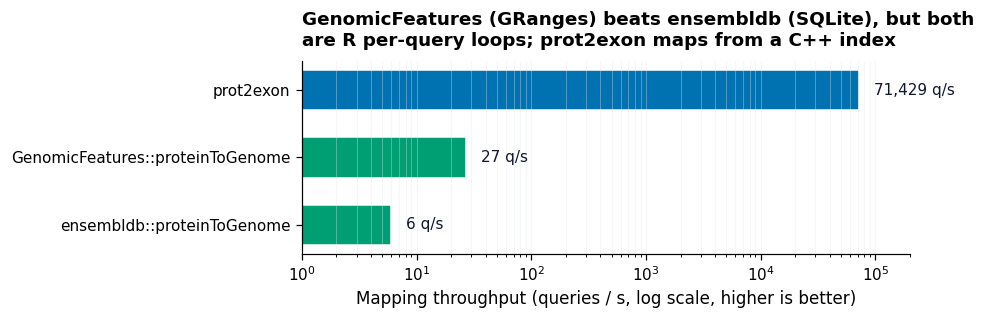

In [7]:
fig, ax = plt.subplots(figsize=(8.8, 3.0))
order = granges.iloc[::-1]  # prot2exon ends up on top
bar_colors = [COLORS['prot2exon'] if t == 'prot2exon' else COLORS['ensembldb']
              for t in order['tool']]
bars = ax.barh(order['tool'], order['map_q_per_s'],
               color=bar_colors, edgecolor='white', height=0.6)
ax.set_xscale('log')
ax.set_xlabel('Mapping throughput (queries / s, log scale, higher is better)')
ax.set_title('GenomicFeatures (GRanges) beats ensembldb (SQLite), but both\n'
             'are R per-query loops; prot2exon maps from a C++ index',
             loc='left')
for y, (_, r) in enumerate(order.iterrows()):
    ax.text(r['map_q_per_s'] * 1.35, y, f"{int(r['map_q_per_s']):,} q/s",
            va='center', fontsize=10, color='#0f172a')
ax.set_xlim(1, 200000)
ax.grid(axis='x', which='both', alpha=0.35, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout(); plt.show()

## 4. VisProDom: a batch mapper with no index

VisProDom (R/Shiny) is presented as a domain viewer, but its `CreDat()`
function is a real batch mapper (pure R/dplyr, cumulative-CDS arithmetic,
the same idea prot2exon implements in C++). It builds **no index**, so it
is O(genome) per call: it rebuilds every transcript's CDS layout on each
invocation.

Running its bundled maize example (`benchmarks/visprodom_bench.R`) at
100, 1,000, and 10,000 query domains shows the signature of an index-free
tool: **wall time is essentially flat** regardless of how many domains
you ask for, because the cost is the genome rebuild, not the query
count. That recompute-per-call model is exactly what prot2exon's
persistent binary index removes.

In [8]:
# Measured: benchmarks/visprodom_bench.R on VisProDom's bundled maize proteome.
visprodom = pd.DataFrame([
    {"n_domains":   100, "wall_s": 5.61, "mapped_rows":  61483, "rss_mb": 766},
    {"n_domains":  1000, "wall_s": 3.96, "mapped_rows":  65358, "rss_mb": 843},
    {"n_domains": 10000, "wall_s": 4.83, "mapped_rows": 101154, "rss_mb": 859},
])
visprodom

,n_domains,wall_s,mapped_rows,rss_mb
0,100,5.61,61483,766
1,1000,3.96,65358,843
2,10000,4.83,101154,859


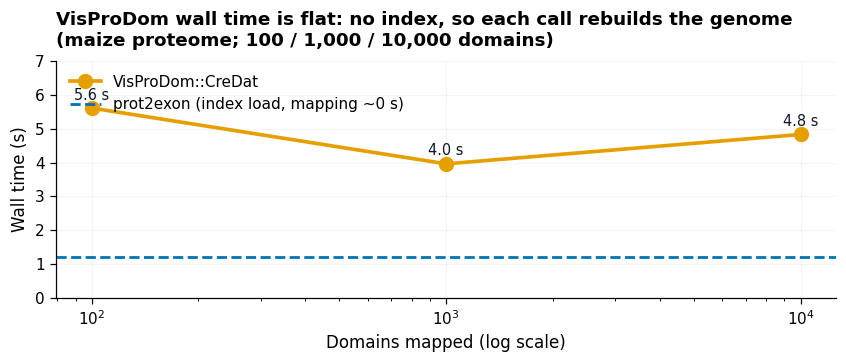

In [9]:
fig, ax = plt.subplots(figsize=(7.8, 3.4))
ax.plot(visprodom['n_domains'], visprodom['wall_s'], 'o-',
        color=COLORS['transvar'], lw=2.4, markersize=9, label='VisProDom::CreDat')
# prot2exon reference: index load (~1.2 s) plus near-zero mapping at these N.
ax.axhline(1.2, ls='--', color=COLORS['prot2exon'], lw=1.8,
           label='prot2exon (index load, mapping ~0 s)')
ax.set_xscale('log')
ax.set_ylim(0, 7)
ax.set_xlabel('Domains mapped (log scale)')
ax.set_ylabel('Wall time (s)')
ax.set_title('VisProDom wall time is flat: no index, so each call rebuilds the genome\n'
             '(maize proteome; 100 / 1,000 / 10,000 domains)', loc='left')
for x, w in zip(visprodom['n_domains'], visprodom['wall_s']):
    ax.text(x, w + 0.25, f"{w:.1f} s", ha='center', fontsize=9.5, color='#0f172a')
ax.legend(loc='upper left'); ax.grid(alpha=0.4, lw=0.7)
fig.tight_layout(); plt.show()

## 5. geneplot: a per-gene plotter that also maps

geneplot (Python; `gffutils` + BioPython) is built to draw one gene at a
time with its domains and SNPs, but internally it **does** map: its
`_transcriptpos_to_genomepos()` walks the gene's CDS to turn protein /
transcript coordinates into genomic ones. So it belongs here, not just
next to prot2exon's plotter.

Measured on its bundled fruit-fly sample, the mapping core runs at about
**0.6 ms per gene (~1,680 genes/s)** once the gene is loaded. Two
caveats keep it apart from the batch mappers above: it builds a `gffutils`
SQLite database from the GFF3 first (cheap on a one-gene sample, O(genome)
on a real annotation), and it is **one gene per call** with a
per-nucleotide coordinate array, so it is aimed at single-gene figures
rather than proteome-scale batches. prot2exon maps from a pre-built index
and returns the per-CDS-exon table directly.

## What this tells you

- **prot2exon is ~900x faster than ensembldb** at N = 10,000, with the same intervals and a smaller index.
- **~4.4x faster than TransVar** with no FASTA bundle required, and **~5,400x faster than Ensembl REST** (REST is HTTP-bound, not rate-limited at the cap).
- **Both Bioconductor mappers agree, and both are slow.** On a fresh 1,000-query v86 run, prot2exon, GenomicFeatures, and ensembldb return identical coordinates; GenomicFeatures (the in-memory GRanges path) is ~3.7x faster end-to-end than ensembldb but still ~2,700x slower per query than prot2exon.
- **Index-free tools do not scale.** VisProDom's wall time is flat at 100 / 1,000 / 10,000 domains because it rebuilds the genome each call; geneplot is fast per gene but is one-gene-at-a-time. prot2exon pays the genome cost once (index build) and then maps in microseconds.
- The R/Shiny tools return the **genomic envelope only**; prot2exon returns the per-CDS-exon decomposition the wiki's [Output description](https://github.com/SotoLF/Prot2Exon/wiki/Mapping#output-description) describes.
- Only prot2exon scales past these toy N values: the others cap at 1,000 to 10,000 (they extrapolate to hours or rebuild per call), while prot2exon runs to 1,000,000 queries in the [`scaling_and_ram.ipynb`](https://github.com/SotoLF/Prot2Exon/blob/main/notebooks/scaling_and_ram.ipynb) notebook.